In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# What is the causal effect of a client's decision to open a deposit?

- `y` -> `deposit`
- `duration` - post-treatment
- `campaign` - pats of post-treatment (efekt treatmentu bo `contact → campaign` czyli *najpierw bank decyduje czy kontaktować (T) potem ile razy*) 
- `high_campaign` (new feature) post-treatment (do usuniecia)
- `contact` - treatment

Treatment (T) → czy klient był intensywnie targetowany

Outcome (Y) → deposit

Confounders (X) → demografia + finanse + historia

In [2]:
# Wczytanie przetworzonego zbioru (feature engineering wykonany w 04_1_simple_feature_engineering.ipynb)
df = pd.read_csv('../data/processed/bank_data_preprocessed_v2.csv')


In [4]:
df.head()

,age,job,marital,default,housing,loan,month,duration,pdays,deposit,...,month_dec,month_feb,month_jan,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep
0,59,admin.,married,no,yes,no,may,1042,-1,1,...,False,False,False,False,False,False,True,False,False,False
1,56,admin.,married,no,no,no,may,1467,-1,1,...,False,False,False,False,False,False,True,False,False,False
2,41,technician,married,no,yes,no,may,1389,-1,1,...,False,False,False,False,False,False,True,False,False,False
3,55,services,married,no,yes,no,may,579,-1,1,...,False,False,False,False,False,False,True,False,False,False
4,54,admin.,married,no,no,no,may,673,-1,1,...,False,False,False,False,False,False,True,False,False,False


In [5]:
df['treatment'] = (df['contact_cellular'] == 'cellular').astype(int)

In [6]:
# historia kontaktów
# proxy dla propensity score

# df['contact_intensity_past'] = df['previous_log1p'] # log(1 + previous) - intensywność kontaktów w przeszłości

In [7]:
df = pd.get_dummies(df, columns=['marital'], drop_first=True) # job?

In [8]:
# transofrmacje nieliniowe

# balance
# df['balance_shifted'] = df['balance'] - df['balance'].min() + 1 # był NaN dla `x < -1 → log(negative) → NaN ❌`
# df['log_balance'] = np.log(df['balance_shifted'])



In [9]:
# age
df['age_squared'] = df['age'] ** 2

In [10]:
# nie  propensity proxy bo działa na campaign ktora jest colliderem
# kontekście estymacji przyczynowego efektu kontaktu jest po-treatment i należy ją wykluczyć.
# - Nie można używać high_campaign w modelu propensity score dla treatment contact.
# # - Nie można używać jako confoundera, bo wprowadziłby post-treatment bias (tzw. collider).
# ❌ Nie używać w causal inference dla contact → deposit
# df['high_campaign'] = (df['campaign'] > df['campaign'].median()).astype(int)

In [11]:
# ----------------------------
# USUWANIE ZBĘDNYCH KOLUMN
# ----------------------------

columns_to_drop = [
    'balance',        # zastąpione przez log_balance, balance_shifted, net_balance_indicator
    'housing',        # połączone w has_debt i financial_stress
    'loan',           # połączone w has_debt i financial_stress
    'default',        # połączone w financial_stress
    'education',      # zastąpione przez dummies: education_secondary, education_tertiary, education_unknown
    'marital',        # zastąpione przez dummies: marital_married, marital_single
    'month',          # zastąpione przez dummies month_2 ... month_12
    'duration',       # collider / post-treatment
    'campaign',       # post-treatment
]

# kolumny, które są już w prop score lub po transformacjach
# pdays -> was_contacted_before
# previous -> contact_intensity_past
# contact -> treatment (możesz zostawić lub całkowicie usunąć)
# age zostawiamy jeśli chcemy razem z age_squared i age_bin

df = df.drop(columns=columns_to_drop, errors='ignore')  # errors='ignore' chroni przed KeyError

# ----------------------------
# Finalny zbiór zmiennych
# ----------------------------
print("Finalne kolumny zbioru:")
print(df.columns)

Finalne kolumny zbioru:
Index(['age', 'job', 'pdays', 'deposit', 'was_previously_contacted',
       'pdays_contacted', 'has_debt', 'net_balance_indicator',
       'financial_stress', 'previous_log1p', 'balance_log1p',
       'campaign_capped', 'poutcome_is_unknown', 'contact_is_unknown',
       'poutcome_failure', 'poutcome_other', 'poutcome_success',
       'contact_cellular', 'contact_telephone', 'education_primary',
       'education_secondary', 'education_tertiary', 'education_unknown',
       'is_peak_month', 'deposit_bin', 'month_apr', 'month_aug', 'month_dec',
       'month_feb', 'month_jan', 'month_jul', 'month_jun', 'month_mar',
       'month_may', 'month_nov', 'month_oct', 'month_sep', 'treatment',
       'marital_married', 'marital_single', 'age_squared'],
      dtype='str')


### Corelation Analyse

### 3. Korelacje i istotności

In [13]:
# # 1. Korelacja dla cech binarnych vs target
# binary_cols = [c for c in df.columns if df[c].dtype == 'bool' or (df[c].dtype == 'int64' and df[c].nunique() == 2)]
# binary_cols = [c for c in binary_cols if c != 'deposit_numeric']

# X_bin = df[binary_cols].astype(int)
# y_bin = df['deposit_numeric']

# from sklearn.feature_selection import chi2

# chi_scores, p_values = chi2(X_bin, y_bin)

# chi_df = pd.DataFrame({
#     'feature': binary_cols,
#     'chi2': chi_scores,
#     'p_value': p_values
# }).sort_values(by='chi2', ascending=False)

# print(chi_df.head(20))

import pandas as pd
import numpy as np
from sklearn.feature_selection import chi2

# 1. Target
y_bin = df['deposit'].astype(int)

# 2. Lepszy wybór kolumn binarnych
binary_cols = [
    c for c in df.columns
    if (
        df[c].nunique(dropna=True) == 2
        and c != 'deposit'
        and c != 'deposit_bin'  # ← dodaj to
    )
]

# 3. Usunięcie braków i konwersja
X_bin = df[binary_cols].copy()

# zamiana bool + object na 0/1
for col in X_bin.columns:
    X_bin[col] = X_bin[col].map({False: 0, True: 1}).fillna(X_bin[col])

# finalna konwersja
X_bin = X_bin.apply(pd.to_numeric, errors='coerce').fillna(0).astype(int)

# 4. Chi-square
chi_scores, p_values = chi2(X_bin, y_bin)

# 5. Wyniki
chi_df = pd.DataFrame({
    'feature': binary_cols,
    'chi2': chi_scores,
    'p_value': p_values
}).sort_values(by='chi2', ascending=False)

print(chi_df)

                     feature        chi2        p_value
8           poutcome_success  829.110985  2.528999e-182
5         contact_is_unknown  578.380144  8.441765e-128
15             is_peak_month  455.469236  4.654513e-101
0   was_previously_contacted  443.598786   1.783277e-98
1                   has_debt  282.098055   2.620593e-63
24                 month_may  242.407391   1.174350e-54
23                 month_mar  199.685434   2.446118e-45
26                 month_oct  192.761120   7.937076e-44
3           financial_stress  189.401853   4.294323e-43
27                 month_sep  174.615519   7.263867e-40
9           contact_cellular  155.505749   1.085609e-35
4        poutcome_is_unknown  150.637570   1.257778e-34
16                 month_apr   84.743198   3.397460e-20
18                 month_dec   83.583952   6.106680e-20
29            marital_single   68.453963   1.298745e-16
13        education_tertiary   66.874790   2.893111e-16
28           marital_married   40.859643   1.635

**🔴 Bardzo silne sygnały**

| Feature | chi² | Wniosek |
|---|---|---|
| `poutcome_success` | 829 | Klient z poprzednią udaną kampanią konwertuje w ~91% — najsilniejszy sygnał w zbiorze |
| `contact_is_unknown` | 578 | Brak informacji o kanale kontaktu mocno obniża konwersję — prawdopodobnie klienci bez historii z bankiem |
| `is_peak_month` | 455 | Zgrupowane miesiące szczytu (mar, sep, oct, dec) jako jedna zmienna dają bardzo silny sygnał |
| `was_previously_contacted` | 444 | Samo bycie wcześniej kontaktowanym przez bank to kluczowy sygnał — oddziela nowych od znanych klientów |
| `has_debt` | 282 | Posiadanie długu (kredyt hipoteczny lub pożyczka) silnie obniża konwersję |

---

**🟡 Średnie sygnały**

| Feature | chi² | Wniosek |
|---|---|---|
| `month_may` | 242 | Maj to najgorszy miesiąc — konwersja ~33%, prawdopodobnie masowa kampania o niskiej jakości |
| `month_mar/oct/sep` | 174–200 | Najlepsze miesiące — konwersja 82–90%, ale uwaga na selekcję klientów |
| `financial_stress` | 189 | Skumulowany wskaźnik stresu finansowego potwierdza że finanse klienta mają znaczenie |
| `contact_cellular` | 156 | Kontakt komórkowy działa lepiej niż stacjonarny |
| `poutcome_is_unknown` | 151 | Brak historii kampanii też jest sygnałem — tacy klienci konwertują rzadziej |

---

**🟢 Słabsze ale istotne sygnały** (p < 0.05)

| Feature | chi² | Wniosek |
|---|---|---|
| `marital_single` | 68 | Osoby stanu wolnego częściej biorą depozyt |
| `education_tertiary` | 67 | Wyższe wykształcenie lekko podnosi konwersję |
| `education_primary` | 38 | Podstawowe wykształcenie obniża konwersję |

---

**⚪ Brak istotności** (p > 0.05) — nie używaj w modelu

```
contact_telephone, month_aug, education_unknown
```

---

#### Trzy zdania podsumowania

1. **Historia kampanii dominuje** — `poutcome_success` i `was_previously_contacted` to razem najsilniejszy blok sygnałów, ważniejszy niż jakiekolwiek cechy demograficzne.

2. **Finanse klienta mają realne znaczenie** — `has_debt` i `financial_stress` potwierdzają że zadłużony klient rzadziej wiąże pieniądze w depozycie.

3. **Demografię** (praca, edukacja, stan cywilny) warto włączyć do modelu jako zmienne kontrolne, ale nie są głównymi predyktorami.

In [19]:
# 2. Korelacja dla cech numerycznych vs target
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_cols = [c for c in numeric_cols 
                if c != 'deposit' 
                and c != 'treatment'
                and c != 'deposit_bin'      
                and c != 'deposit_numeric']

corrs = df[numeric_cols + ['deposit']].corr()['deposit'].drop('deposit')
corrs = corrs.sort_values(key=abs, ascending=False)
print(corrs.head(20))

contact_is_unknown         -0.256136
has_debt                   -0.231671
was_previously_contacted    0.230850
poutcome_is_unknown        -0.230470
previous_log1p              0.209330
is_peak_month               0.208702
pdays                       0.151593
pdays_contacted            -0.143814
financial_stress           -0.143693
campaign_capped            -0.136161
balance_log1p               0.111009
net_balance_indicator       0.101447
age_squared                 0.064768
age                         0.034901
Name: deposit, dtype: float64


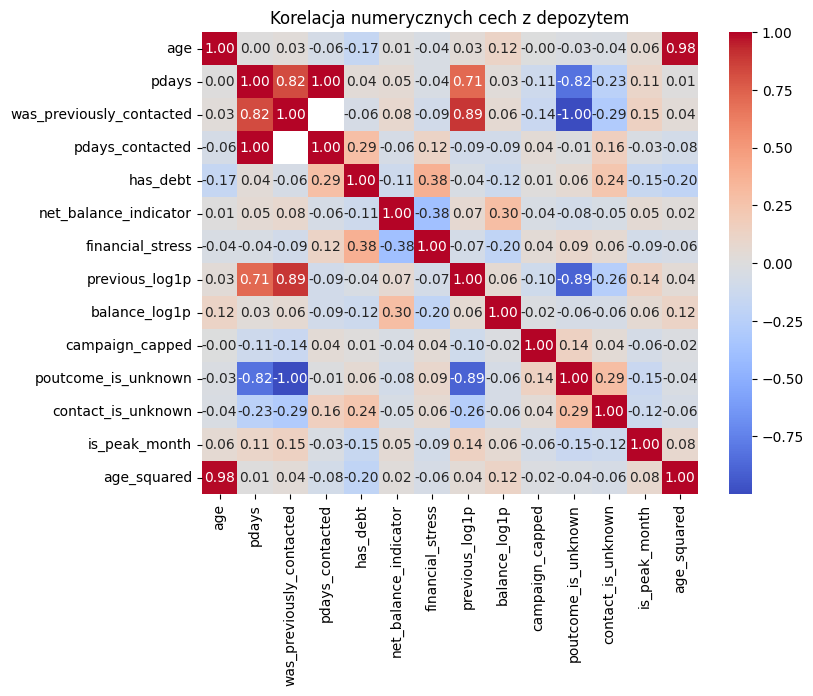

In [20]:
corr = df[numeric_cols].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Korelacja numerycznych cech z depozytem')
plt.show()

**🔴 Najsilniejsze korelacje**

| Feature | Korelacja | Wniosek |
|---|---|---|
| `contact_is_unknown` | -0.256 | Brak informacji o kanale kontaktu silnie obniża konwersję |
| `has_debt` | -0.232 | Zadłużony klient rzadziej otwiera depozyt |
| `was_previously_contacted` | +0.231 | Wcześniejszy kontakt z bankiem zwiększa szansę depozytu |
| `poutcome_is_unknown` | -0.230 | Brak historii poprzedniej kampanii obniża konwersję |
| `previous_log1p` | +0.209 | Im więcej poprzednich kontaktów, tym wyższa konwersja |
| `is_peak_month` | +0.209 | Miesiące szczytu (mar, sep, oct, dec) zwiększają konwersję |

---

**🟡 Średnie korelacje**

| Feature | Korelacja | Wniosek |
|---|---|---|
| `pdays` | +0.152 | Więcej dni od ostatniego kontaktu — zaskakująco pozytywny efekt, prawdopodobnie klienci którzy "ochłonęli" |
| `pdays_contacted` | -0.144 | Im starszy kontakt tym mniejsza szansa — efekt zanikania pamięci |
| `financial_stress` | -0.144 | Skumulowany stres finansowy obniża konwersję |
| `campaign_capped` | -0.136 | Więcej telefonów w tej kampanii = mniejsza konwersja — klient się męczy |
| `balance_log1p` | +0.111 | Wyższe saldo konta zwiększa szansę depozytu |

---

**🟢 Słabe korelacje**

| Feature | Korelacja | Wniosek |
|---|---|---|
| `net_balance_indicator` | +0.101 | Słaby sygnał — dodatnie saldo lekko pomaga |
| `age_squared` | +0.065 | Wiek działa nieliniowo — samo `age` (0.035) nie łapie tego efektu |
| `age` | +0.035 | Bardzo słaby sygnał liniowy |

---

#### Uwaga
**`pdays` vs `pdays_contacted` idą w przeciwnych kierunkach** — to ważne. `pdays` (liczba dni od kontaktu) ma korelację pozytywną, a `pdays_contacted` (czy w ogóle był kontakt dawno temu) negatywną. To znaczy że *sam fakt dawnego kontaktu* szkodzi, ale *długość przerwy* po kontakcie pomaga. Warto to sprawdzić dokładniej przed wrzuceniem do modelu.

**`age_squared` > `age`** — wiek działa nieliniowo. Młodzi i starsi klienci zachowują się podobnie, środek inaczej (albo odwrotnie). W modelu liniowym sam `age` jest bezużyteczny — zostaw tylko `age_squared` albo zrób binning.

In [22]:
df.columns

Index(['age', 'job', 'pdays', 'deposit', 'was_previously_contacted',
       'pdays_contacted', 'has_debt', 'net_balance_indicator',
       'financial_stress', 'previous_log1p', 'balance_log1p',
       'campaign_capped', 'poutcome_is_unknown', 'contact_is_unknown',
       'poutcome_failure', 'poutcome_other', 'poutcome_success',
       'contact_cellular', 'contact_telephone', 'education_primary',
       'education_secondary', 'education_tertiary', 'education_unknown',
       'is_peak_month', 'deposit_bin', 'month_apr', 'month_aug', 'month_dec',
       'month_feb', 'month_jan', 'month_jul', 'month_jun', 'month_mar',
       'month_may', 'month_nov', 'month_oct', 'month_sep', 'treatment',
       'marital_married', 'marital_single', 'age_squared', 'deposit_numeric'],
      dtype='str')

In [ ]:
# czyszczenie zbioru ze zbednych kolumn

# Na pewno do suuniecia
# deposit_bin       # to jest target zakodowany jako 0/1 — to sam target, nie cecha
# deposit_numeric   # to samo
# treatment         # jeśli to kolumna którą sam stworzyłeś jako treatment w CI — 
                  # nie powinna być cechą w modelu

# usunąc -  brak istotności statystycznej (p > 0.05 w chi²)
# contact_telephone  # chi²=2.8, p=0.094 — brak istotności
# month_aug          # chi²=2.7, p=0.103 — brak istotności  
# education_unknown  # chi²=2.2, p=0.138 — brak istotności

# rozważyć usunięcie - redundancja

# # Para 1 — to samo zjawisko z dwóch stron
# contact_is_unknown    # zostaw — silniejszy sygnał (chi²=578, corr=-0.256)
# contact_telephone     # usuń — już nieistotny
# contact_cellular      # zostaw — istotny (chi²=156)

# # Para 2 — redundancja historii kampanii
# poutcome_is_unknown   # zostaw — silny sygnał
# was_previously_contacted  # zostaw — inny wymiar (czy był kontakt)
# pdays_contacted       # rozważ usunięcie — częściowo pokrywa się z was_previously_contacted

# # Para 3 — miesiące vs is_peak_month
# is_peak_month         # zostaw — agregat najlepszych miesięcy, chi²=455
# month_jan             # usuń — chi²=5.1, p=0.023, bardzo słaby
# month_jun             # usuń — chi²=3.6, p=0.058, nieistotny
# month_nov             # usuń — chi²=8.2, p=0.004, słaby
# month_aug             # usuń — już powyżej

# # Para 4 — wiek
# age                   # rozważ usunięcie — corr=0.035, bardzo słaby liniowy
# age_squared           # zostaw jeśli używasz modelu nieliniowego

### Wnioski

#### 1️⃣ Główne cechy (high importance) – silna korelacja z `deposit`

| Cecha | Typ / rola | Uzasadnienie |
|---|---|---|
| `balance_log1p` | Confounder | Wyższe saldo zwiększa szansę depozytu (corr=+0.111). Wpływa na decyzję klienta i może wpływać na to kogo bank wybiera do kontaktu. |
| `age_squared` | Confounder | Wiek działa nieliniowo — `age_squared` lepiej łapie efekt niż samo `age` (corr=0.065 vs 0.035). |
| `was_previously_contacted` | Confounder / proxy propensity | chi²=444, corr=+0.231 — historia kontaktów wpływa na depozyt i koreluje z treatment. |
| `has_debt` | Confounder | chi²=282, corr=-0.232 — zadłużony klient rzadziej otwiera depozyt i może być inaczej targetowany przez bank. |
| `financial_stress` | Confounder | chi²=189, corr=-0.144 — skumulowany wskaźnik ryzyka finansowego, łączy dług i saldo ujemne. |
| `poutcome_success` | Confounder / history effect | chi²=829 — najsilniejszy sygnał w zbiorze. Klient z udaną poprzednią kampanią konwertuje w ~91%. |

**Wskazówka:** te zmienne powinny iść do modelu jako zmienne kontrolne lub do propensity score.

---

#### 2️⃣ Średnie cechy (medium importance) – umiarkowana korelacja lub znaczenie

| Cecha | Typ / rola | Uzasadnienie |
|---|---|---|
| `previous_log1p` | Confounder / proxy propensity | corr=+0.209 — im więcej wcześniejszych kontaktów tym wyższa konwersja. Proxy zaangażowania klienta. |
| `contact_is_unknown` | Post-treatment / selection bias | chi²=578, corr=-0.256 — bardzo silny sygnał ale ryzykowny: brak info o kanale może być efektem procesu bankowego, nie cechą klienta. |
| `is_peak_month` | Confounder sezonowy | chi²=455, corr=+0.209 — miesiące szczytu mają silny efekt, ale uwaga na selekcję klientów w tych miesiącach. |
| `campaign_capped` | Post-treatment | corr=-0.136 — więcej telefonów w kampanii obniża konwersję (efekt zmęczenia), ale zależy od treatment. |
| `pdays` | Post-treatment / collider | corr=+0.152 — liczba dni od ostatniego kontaktu zależy od treatment, użycie w modelu przyczynowym może wprowadzić bias. |

---

#### 3️⃣ Cechy do odrzucenia / ignorowania (low importance / risky)

| Cecha | Typ / rola | Uzasadnienie |
|---|---|---|
| `deposit_bin`, `deposit_numeric` | Leakage | To jest target przebrany za cechę — natychmiast usuń. |
| `treatment` | Treatment | Główna zmienna wyjaśniająca — nie może być cechą w modelu predykcyjnym. |
| `contact_telephone` | Nieistotna | chi²=2.8, p=0.094 — brak istotności statystycznej. |
| `month_aug`, `month_jun`, `month_jan` | Nieistotne | p > 0.05 lub bardzo słabe chi² — nie wnoszą sygnału. |
| `education_unknown` | Nieistotna | p=0.138 — brak istotności. |
| `job` | Niska korelacja / wiele kategorii | Słaby sygnał w kontekście causal — indywidualne kategorie (`student`, `retired`) mają znaczenie, ale cała kolumna wprowadza szum. |
| `pdays_contacted` | Redundantna | Pokrywa się z `was_previously_contacted`, corr=-0.144 — przy zachowaniu obu wprowadzasz multikolinearność. |

---

#### 🔑 Podsumowanie ról

**Confounder** → uwzględnij w modelu / propensity score: `balance_log1p`, `age_squared`, `has_debt`, `financial_stress`, `was_previously_contacted`, `previous_log1p`, `poutcome_success`

**Post-treatment / collider** → nie używaj w modelu przyczynowym: `pdays`, `campaign_capped`, `contact_is_unknown`

**Opcjonalne kontrolki** → słabszy sygnał, można dodać: `is_peak_month`, `marital_single`, `education_tertiary`, `net_balance_indicator`

**Usuń** → `deposit_bin`, `deposit_numeric`, `treatment` (jako cecha), `contact_telephone`, `month_aug/jun/jan`, `education_unknown`, `pdays_contacted`

In [24]:
cols_to_keep = [
    # Target
    'deposit',

    # Historia kampanii — najsilniejszy blok
    'poutcome_success',
    'poutcome_is_unknown',
    'poutcome_failure',      # zostaw jako punkt odniesienia dla poutcome
    'poutcome_other',        # zostaw jako punkt odniesienia dla poutcome
    'was_previously_contacted',
    'previous_log1p',

    # Kontakt
    'contact_is_unknown',
    'contact_cellular',

    # Finanse
    'has_debt',
    'financial_stress',
    'balance_log1p',
    'net_balance_indicator',

    # Sezonowość
    'is_peak_month',
    'month_may',
    'month_mar',
    'month_sep',
    'month_oct',
    'month_dec',

    # Demografia — jako kontrola
    'marital_single',
    'marital_married',       # punkt odniesienia
    'education_tertiary',
    'education_primary',
    'education_secondary',   # punkt odniesienia
    'job',                   # zostaw surową kolumnę — zawiera retired/student

    # Numeryczne
    'pdays',
    'pdays_contacted',
    'campaign_capped',
    'age_squared',
]

df_model = df[cols_to_keep].copy()

print(f"Kolumny: {df_model.shape[1]}")
print(f"Wiersze: {df_model.shape[0]}")
print(df_model.dtypes)

Kolumny: 29
Wiersze: 11162
deposit                       int64
poutcome_success               bool
poutcome_is_unknown           int64
poutcome_failure               bool
poutcome_other                 bool
was_previously_contacted      int64
previous_log1p              float64
contact_is_unknown            int64
contact_cellular               bool
has_debt                      int64
financial_stress              int64
balance_log1p               float64
net_balance_indicator         int64
is_peak_month                 int64
month_may                      bool
month_mar                      bool
month_sep                      bool
month_oct                      bool
month_dec                      bool
marital_single                 bool
marital_married                bool
education_tertiary             bool
education_primary              bool
education_secondary            bool
job                             str
pdays                         int64
pdays_contacted             float64
c

In [25]:
df_model.to_csv('../data/processed/bank_data_cleaned.csv', index=False)

In [26]:
df_selected = df[cols_to_keep].copy()

df_selected.glimpse()

<class 'pandas.DataFrame'>: 11162 rows of 29 columns
deposit:                   int64             [1, 1, 1, 1, 1, 1, 1, 1, 1, ...
poutcome_success:          bool              [False, False, False, False ...
poutcome_is_unknown:       int64             [1, 1, 1, 1, 1, 1, 1, 1, 1, ...
poutcome_failure:          bool              [False, False, False, False ...
poutcome_other:            bool              [False, False, False, False ...
was_previously_contacted:  int64             [0, 0, 0, 0, 0, 0, 0, 0, 0, ...
previous_log1p:            float64           [0.0, 0.0, 0.0, 0.0, 0.0, 0 ...
contact_is_unknown:        int64             [1, 1, 1, 1, 1, 1, 1, 1, 1, ...
contact_cellular:          bool              [False, False, False, False ...
has_debt:                  int64             [1, 0, 1, 1, 0, 1, 1, 1, 1, ...
financial_stress:          int64             [0, 0, 0, 0, 0, 1, 1, 0, 0, ...
balance_log1p:             float64           [9.126088819528592, 8.83840 ...
net_balance_indicator: 